In [40]:
import numpy as np
import matplotlib.pyplot as plt
import librosa

## Etapa 1: Caracterización Estocástica y Frecuencial

Falta...
- Definir las bandas de frecuencias con más energía concentrada.
- Definir si son ergódicas y estacionarias a tramos (definir duración) o en su totalidad.

In [41]:
audio, fs = librosa.load("audio/voz_original.wav", sr=None)

print(audio.shape)
print(fs)

(64000,)
8000


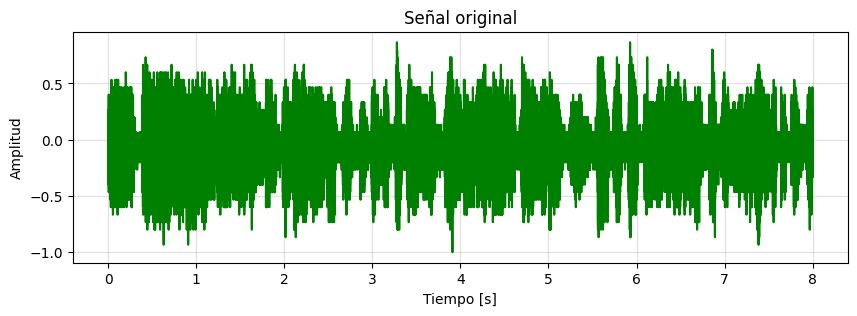

Potencia media = 0.04772217944264412


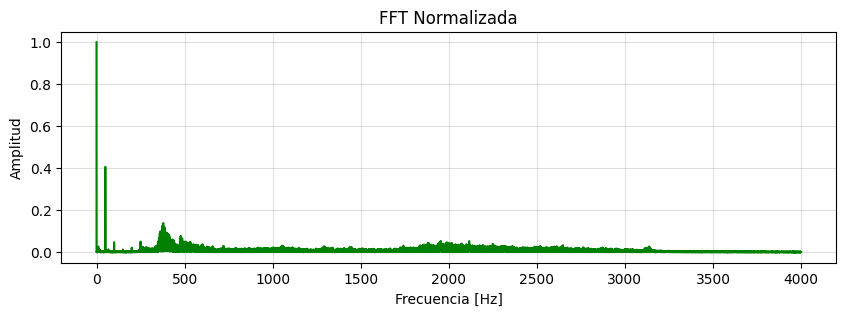

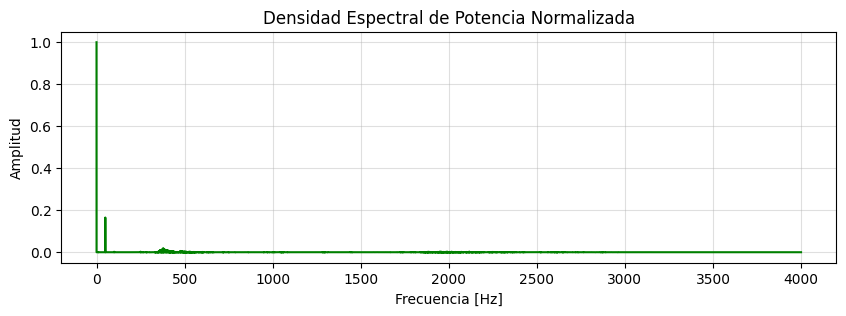

Entropía de la señal: 3.6654300421289303
Entropía de la PSD: 11.093448638916016


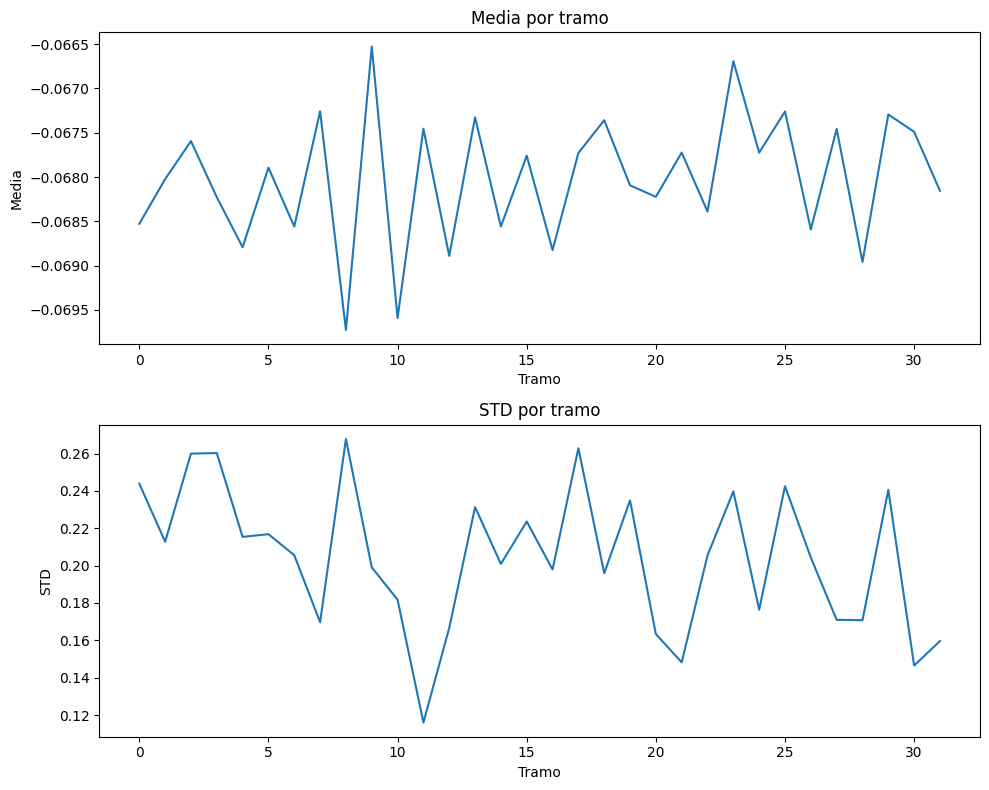

In [52]:
def graf_temp(signal, fs, figsize=(10,3)):
    dom = np.arange(len(signal)) * 1/fs
    plt.figure(figsize=figsize)
    plt.title("Señal original")
    plt.ylabel("Amplitud")
    plt.xlabel("Tiempo [s]")
    plt.plot(dom, signal, c='green')
    plt.grid(True, alpha=0.4)
    plt.show()

def graf_fft(signal, fs, figsize=(10,3), ylim=None, xticks=None):
    N = len(signal)
    
    fft = np.fft.rfft(signal, N)
    mag = np.abs(fft)
    mag /= np.max(mag)
    dom = np.fft.rfftfreq(N, 1/fs)

    plt.figure(figsize=figsize)
    plt.title("FFT Normalizada")
    plt.ylabel("Amplitud")
    if ylim is not None:
        plt.ylim(0, ylim)

    if xticks is not None:
        plt.xticks(np.arange(0, fs/2 + xticks, xticks))
    plt.xlabel("Frecuencia [Hz]")
    plt.plot(dom, mag, c='green')
    
    plt.grid(True, alpha=0.4)
    plt.show()   

def calc_fft(signal, fs):
    N = len(signal)    
    fft = np.fft.rfft(signal, N)
    mag = np.abs(fft)
    dom = np.fft.rfftfreq(N, 1/fs)  
    return dom, mag

def graf_psd(signal, fs, figsize=(10,3), ylim=None, xticks=None):
    N = len(signal)
    
    fft = np.fft.rfft(signal, N)
    mag = np.abs(fft)
    psd = mag ** 2
    psd /= np.max(psd)
    dom = np.fft.rfftfreq(N, 1/fs)

    plt.figure(figsize=figsize)
    plt.title("Densidad Espectral de Potencia Normalizada")
    plt.ylabel("Amplitud")
    if ylim is not None:
        plt.ylim(0, ylim)

    if xticks is not None:
        plt.xticks(np.arange(0, fs/2 + xticks, xticks))
    plt.xlabel("Frecuencia [Hz]")
    plt.plot(dom, psd, c='green')
    
    plt.grid(True, alpha=0.4)
    plt.show()
    return dom, psd

def calc_psd(signal, fs):
    N = len(signal)
    
    fft = np.fft.rfft(signal, N)
    mag = np.abs(fft)
    psd = mag ** 2
    dom = np.fft.rfftfreq(N, 1/fs)
    return dom, psd

def calc_potencia(signal):
    return np.mean(np.abs(signal)**2)

def calc_entropia(P):
    # Recibe histograma o PSD
    return -np.sum(P * np.log2(P))    

def obtener_tramos(signal, fs, ms, lap, start):
    N = len(signal)
    duracion_ventana = int(ms * fs/1000)
    desplazamiento = int(lap * fs/1000)
    arranque = int(start * fs/1000)

    tramos = [] # n_señales x algo 
    cant_tramos = (N - duracion_ventana)//desplazamiento + 1

    for j in range(cant_tramos):
        tramo = signal[arranque + desplazamiento * j : arranque + desplazamiento * j + duracion_ventana]
        if len(tramo) == duracion_ventana:
            tramos.append(tramo)
    return np.array(tramos)

def graf_stats(signal, fs, ms, figsize=(10,8)):
    tramos = obtener_tramos(signal, fs, ms, lap=ms, start=0)
    dom = np.arange(len(tramos))
    media = np.mean(tramos, axis=1)
    std = np.std(tramos, axis=1)

    plt.figure(figsize=figsize)
    plt.subplot(2,1,1)
    plt.title("Media por tramo")
    plt.ylabel("Media")
    plt.xlabel("Tramo")
    plt.plot(dom, media)

    plt.subplot(2,1,2)
    plt.title("STD por tramo")
    plt.ylabel("STD")
    plt.xlabel("Tramo")
    plt.plot(dom, std)
    
    plt.tight_layout()
    plt.show()
    
    



_ = graf_temp(audio, fs)
print(f"Potencia media = {calc_potencia(audio)}")
graf_fft(audio, fs)
graf_psd(audio, fs)

_, psd = calc_psd(audio, fs)

hist, _ = np.histogram(audio, bins=50)
prob_hist = hist/np.sum(hist)
prob_hist = prob_hist[prob_hist > 0]

prob_psd = psd/np.sum(psd)
prob_psd = prob_psd[prob_psd > 0]
print(f"Entropía de la señal: {calc_entropia(prob_hist)}")
print(f"Entropía de la PSD: {calc_entropia(prob_psd)}")

graf_stats(audio, fs, ms=250)

## Etapa 2: Filtrado Digital

In [ ]:
wc = 1000
